question 1 - using a traditional, non neural network approach to predict the species of a penguin given the penguins culmen length, culmen depth, flipper length and body mass. I have decided to do this using a random forest method, using datacamp for help. I will use 80% of the data set to train the model to classify the species of penguin and then 20% to test the trained dataset on. The Scikit-learn python package was very important for this method.

A key assumption is that the penguins used to collect this data are all adults and their age does not impact the data.

I answered this question following the tutorial from [datacamp.com ](https://www.datacamp.com/tutorial/random-forests-classifier-python) and recieved a lot of support from my dad and my sister.

Random forests are a traditional, non neural network approach to machine learning that works well in classification. It averages the result of many individual trees which offsets any biases and increases precision. The data cleaning and processing was very straight forward, and feature importance is easily calculated which allows easy analysis of how the data was classified and why.

To start off, we need to import some python packages that are necessary for the code to work. Pandas allows us to see the data in a dataframe, which is similar to a spreadsheet, and numpy gives us a large range of mathematical abilities. Matplotlib allows for data visualisation.

In [5]:
#import files to help with funtions being called from another file - chatgpt suggestion
import sys
import os
sys.path.append(os.path.abspath(".."))

In [6]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Next, some specific features from Scikit-learn need to be imported to help us normalise the data and calculate the accuracy of the predictions. 

In [7]:
#scikit-learn imports
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

Finally, our helper functions need to be imported. These are functions that I have written in a seperate file to keep this notebook easily readable. They do the bulk of the work, such as importing the data, splitting it into training and testing sets and calculating the accuracy of the reandom forest. The purpose of each function is commented next to each import.

In [8]:
from functions import load_data #this function retrieves the data from where its stored
from functions import split_data #this function splits the data into a target and features.
from functions import split_train_test #this function splits the data into training and testing sets with a 80-20 split
from functions import train_random_forest #this function trains our random forest classifier on the training data
from functions import evaluate_model #this function evaluates the accuracy of the trained model
from functions import feature_importance #this function evaluates the importance of each feature in the model

To start, we need to get the data from the source. The data has 7 columns, for species, island, culmen length, culmen depth, flipper length, body mass and sex. The penguins island of residence and sex has no impact on the species of gender, so any missing values are acceptable. However, the other 4 values are all important to determining the species of the penguin. The data has been cleaned by removing any null values, so the data loaded by the load_data function is clean and ready to use and anaylse.

In [ ]:
#loading in the clean penguin size data and showing the first 5 rows of data.
df = load_data("../../data/processed/penguins_size_cleaned.csv") #loading the data
df.head() #displaying the first 5 rows

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


The data has been imported into our notebook, and a small portion of it is shown. We do not want to train the model on all of the data columns because it isnt necessary, so next we need to set some parameters and tell the model to train only on the culmen length, depth, flipper length, and body mass. In the split_data function, the data is split into a target to predict (species) and features to base the prediction on (culmen length, depth, flipper length, body mass). Below we will set the values and then use the function to split the data into a target column and feature columns, which are the parameters the function needs. 

In [ ]:
#splitting the data into feature data and target data
feature_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g',] #setting features
target_col = 'species' #setting the target
x, y = split_data(df, feature_cols, "species") #splitting the data into features and target

Next, we need to use some of the data to train the random forest model. The random forest model works by choosing a subset of the dataset (in our case, 80%), called bootstrapping, and then training the 'trees' on this data until they can all come to their own individual conclusion. The results are then averaged across each tree so that the most commonly predicted outcome is selected, which is called aggregation. This entire process is called bagging. To start bagging, we need to split the data using the split_train_test function to give us 2 datasets, one containing 80% of the for training and the other containing 20% used for testing. 80-20 was chosen because it gives enough data to train the model on while also keeping enough data to test the model.

In [ ]:
#creating test and train sets for both x and y using the split_test_train function
#test size 0.2 means 20% of the data is reserved for testing
#random state 42 is used to select a set of samples that can be reproduced
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size=0.2, random_state=42) #splitting the data

Finally, the data has been prepared and it is time to actually start training the model using the train_random_forest function. It takes the training sets allocated above for both x (features) and y (target), a number of trees to use and a random state seed. The x and y training sets from above will be used, as well as 100 trees to get many outputs from the model to average. A large number of trees ensures that the data points are less likely to be overlooked and the output is more accurate. 42 is a random number selected for the random state (and was suggested by vscode).

In [ ]:
#training the random forest to identify the penguin species based on the training data
clf = train_random_forest(x_train, y_train, n_estimators=100, random_state=42) #training the random forest

The model has now been trained on the data and should be able to give us a prediction of a penguins species based on the feature data. We can now use the evaluate_model function to see how accurately the model can predict the target based on the 20% of the data reserved for testing.

In [ ]:
#evaluating the performance of the model
evaluate_model(clf, x_test, y_test) #evaluating the model with the evaluate_model function

(0.9565217391304348,
 '              precision    recall  f1-score   support\n\n      Adelie       1.00      0.91      0.96        35\n   Chinstrap       0.80      1.00      0.89        12\n      Gentoo       1.00      1.00      1.00        22\n\n    accuracy                           0.96        69\n   macro avg       0.93      0.97      0.95        69\nweighted avg       0.97      0.96      0.96        69\n')

The accuracy of the model is 95.65%, meaning that it predicted the correct species of penguin 95.65% of the time using the test data. This shows that the culmen length, depth, flipper length and body mass of a penguin are very effective at predicting the species. There is a clear difference in features between species, so the high accuracy was expected given the chosen dataset. Random forest models work well for well tabulated data, like the penguin size data, so while it works well for this it will not work as well for other datasets with different types or unbalanced data.

Another feature of scikit-learn is the confusion matrix, which shows the areas that the model got most confused between. We can now use this built-in feature to look at these areas.

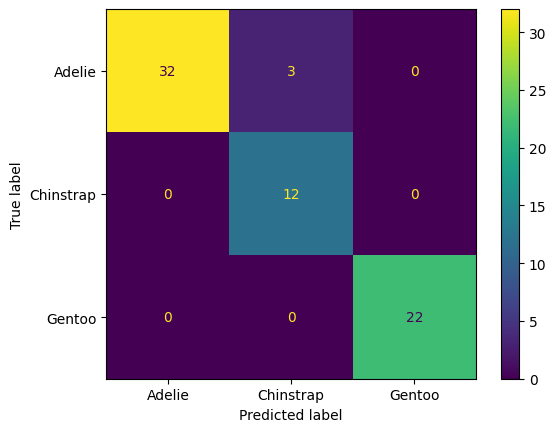

In [ ]:
#using the confusion matrix to display areas the model found confusing
ConfusionMatrixDisplay.from_estimator(clf, x_test, y_test) #generating and displaying confusion matrix
plt.savefig("../../images/01_confusion_matrix.png") #saving the image to the image folder

The confusion matrix shows that chinstrap and gentoo were never misidentified, but adelie was incorrectly predicted to be chinstrap 3 times. 

The last piece of evaluation we can do is using feature_importance to determine which of the features correlate most strongly with the penguins species and see which helped most to predict the outcomes. Random forests show this off quite well compared to other models. 

In [ ]:
#using feature_importance to see which features were most important in the model
feature_importance(clf, feature_cols) #printing feature importance for each value

,Feature,Importance
0,culmen_length_mm,0.417756
2,flipper_length_mm,0.306551
1,culmen_depth_mm,0.191830
3,body_mass_g,0.083863


Feature importance shows us that the culmen length was most important to determine the species of penguin, followed by flipper length, culmen depth, then body mass. This shows us that the penguins have a large difference in their culmen length and flipper length, a moderate difference in culmen depth and very little variation in body mass, as the model didnt really need it to predict penguin species. 

The random forest worked quite well for my chosen dataset, as it works well with tabular data and provided good accuracy. It didnt require much preparation of the data aside from needing to remove the null values and the results were as expected and easy to interpret. However, the good performance did depend on the dataset I chose being balanced and having few outliers so it likely wouldnt work as effectively for non balanced datasets or non tabular data. It also placed a great deal of importance on some features as opposed to others, such as culmen length having an importance score of approx 0.42 compared to body mass having a score of 0.08. 

To conclude, I chose this approach due to its ease of use and interpretability and how well suited it is to my chosen dataset. I think it worked quite well as shown by the accuracy score of ~96% and I found it easy to prepare for and impliment. 